# **🍔 Fast Food Cheat Meal: Workout Penalty Predictor**
**What this notebook does (step by step):**
1. Load and explore the data
2. Spot and avoid *data leakage* (very important!)
3. Create simple new features
4. Train models from a baseline to the best one
5. Compare results and write a conclusion

**Goal:** Predict `workout_shock_tier` (how hard you must exercise to burn a fast-food meal) using only information known *before* any burn calculation.

In [1]:
import pandas as pd, numpy as np, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore'); sns.set_style('whitegrid')

## **1. Load the data**

In [2]:
import os
path = next((os.path.join(d, f) for d, _, fs in os.walk('/kaggle/input') for f in fs if f.endswith('.csv')), '/kaggle/input/datasets/samartalwar/fast-food-calorie-shock-food-vs-workout-burn/fast_food_cheat_meal_workout_burn.csv')
df = pd.read_csv(path)
print(df.shape); print('Missing values:', df.isna().sum().sum()); df.head()

(8000, 23)
Missing values: 0


,order_id,fast_food_chain,meal_category,item_count,total_calories,fat_grams,saturated_fat_grams,carb_grams,sugar_grams,protein_grams,...,consumer_weight_kg,fitness_level,thermic_effect_calories,net_caloric_surplus,walking_burn_time_min,cycling_burn_time_min,running_burn_time_min,hiit_burn_time_min,daily_calorie_allowance_pct,workout_shock_tier
0,FFC-00001,McDonald's,Late-Night Value Menu Binge,3,1015,47,19,117,55,32,...,96.0,Moderately Active,77.9,937.1,168.3,80.8,60.2,46.5,50.7,High Sweat Penalty
1,FFC-00002,Taco Bell,Fried Chicken Bucket & Slaw,5,1849,103,32,166,61,65,...,53.6,Moderately Active,136.7,1712.3,550.7,261.7,185.5,161.1,92.4,Extreme / Half-Marathon Toll
2,FFC-00003,Domino's Pizza,Pizza Feast & Cheesy Bread,2,1920,106,50,184,61,57,...,67.0,Moderately Active,135.0,1785.0,463.9,219.5,157.8,131.1,96.0,Extreme / Half-Marathon Toll
3,FFC-00004,McDonald's,Dessert Overload & Large Shake,2,1255,67,25,135,42,27,...,62.6,Sedentary,82.3,1172.7,351.0,166.5,120.3,103.4,62.7,Extreme / Half-Marathon Toll
4,FFC-00005,Taco Bell,Double Burger & Large Fry,4,1665,88,32,155,69,62,...,73.0,Moderately Active,127.4,1537.6,361.3,170.9,119.1,104.9,83.2,Severe Cardio Deficit


## **2. Quick exploration (EDA)**

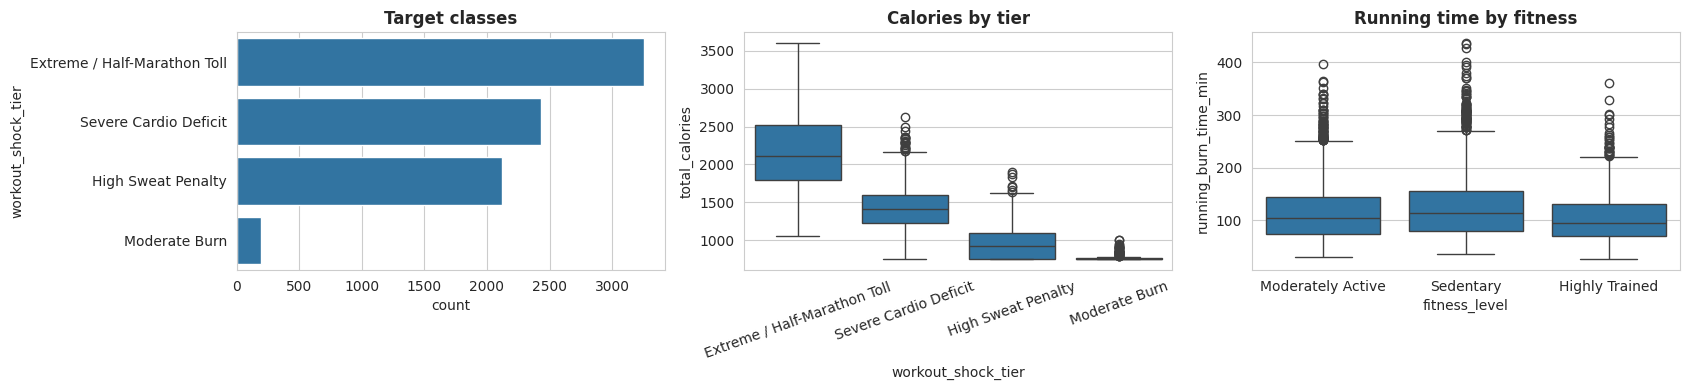

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
order = df.workout_shock_tier.value_counts().index
sns.countplot(y='workout_shock_tier', data=df, order=order, ax=ax[0]); ax[0].set_title('Target classes',fontweight='bold')
sns.boxplot(x='workout_shock_tier', y='total_calories', data=df, order=order, ax=ax[1]); ax[1].set_title('Calories by tier',fontweight='bold'); ax[1].tick_params(axis='x', rotation=20)
sns.boxplot(x='fitness_level', y='running_burn_time_min', data=df, ax=ax[2]); ax[2].set_title('Running time by fitness',fontweight='bold')
plt.tight_layout(); plt.show()

**Observations:** The classes are imbalanced (`Moderate Burn` is rare), so we will track **macro F1** as well as accuracy.

## **3. ⚠️ Data leakage check**
The tier looks like it is defined by `running_burn_time_min` (e.g. under 45 min = Moderate Burn). Let's confirm.

In [4]:
print(df.groupby('workout_shock_tier').running_burn_time_min.agg(['min','max']).round(1))

                                min    max
workout_shock_tier                        
Extreme / Half-Marathon Toll  120.1  436.5
High Sweat Penalty             45.1   80.0
Moderate Burn                  26.3   45.0
Severe Cardio Deficit          80.1  120.0


The ranges do **not overlap**, so the burn-time columns, `net_caloric_surplus`, `thermic_effect_calories` and `daily_calorie_allowance_pct` would give the answer away. A model using them would score ~100% but be useless in real life.

✅ We keep only **meal + person** information: nutrition values, chain, category, age, weight, gender, fitness level.

## **4. Feature engineering (simple and meaningful)**

In [5]:
target = 'workout_shock_tier'
cat = ['fast_food_chain', 'meal_category', 'consumer_gender', 'fitness_level']
num = ['item_count', 'total_calories', 'fat_grams', 'saturated_fat_grams', 'carb_grams',
       'sugar_grams', 'protein_grams', 'sodium_mg', 'consumer_age', 'consumer_weight_kg']

X = df[cat + num].copy()
X['cal_per_kg'] = X.total_calories / X.consumer_weight_kg          # heavier people burn more
# fitter people burn calories faster -> smaller factor = faster burn
factor = {'Highly Trained': 5.4, 'Moderately Active': 5.83, 'Sedentary': 6.34}
X['run_time_est'] = X.total_calories * 0.924 * X.fitness_level.map(factor) / X.consumer_weight_kg
num_all = num + ['cal_per_kg', 'run_time_est']

le = LabelEncoder(); y = le.fit_transform(df[target])
print(dict(zip(le.classes_, range(4))))

{'Extreme / Half-Marathon Toll': 0, 'High Sweat Penalty': 1, 'Moderate Burn': 2, 'Severe Cardio Deficit': 3}


## **5. Train / test split and preprocessing**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat),
                         ('num', StandardScaler(), num_all)])
print(X_train.shape, X_test.shape)

(6400, 16) (1600, 16)


## **6. Train models: baseline → best**
We try 5 models, from the simplest to the strongest, and compare them on the test set and with 5-fold cross-validation.

In [7]:
models = {
    'Baseline (most frequent)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=3000, C=10),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, random_state=42),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows, fitted = [], {}
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); fitted[name] = pipe
    rows.append({'Model': name,
                 'Test Accuracy': accuracy_score(y_test, pred),
                 'Macro F1': f1_score(y_test, pred, average='macro'),
                 'CV Accuracy': cross_val_score(pipe, X_train, y_train, cv=cv).mean()})
results = pd.DataFrame(rows).sort_values('Macro F1', ascending=False).round(4).reset_index(drop=True)
results

,Model,Test Accuracy,Macro F1,CV Accuracy
0,Random Forest,0.9419,0.8906,0.9486
1,Logistic Regression,0.9381,0.8829,0.9441
2,Decision Tree,0.9381,0.8802,0.9420
3,Hist Gradient Boosting,0.9356,0.8701,0.9434
4,Baseline (most frequent),0.4075,0.1448,0.4070


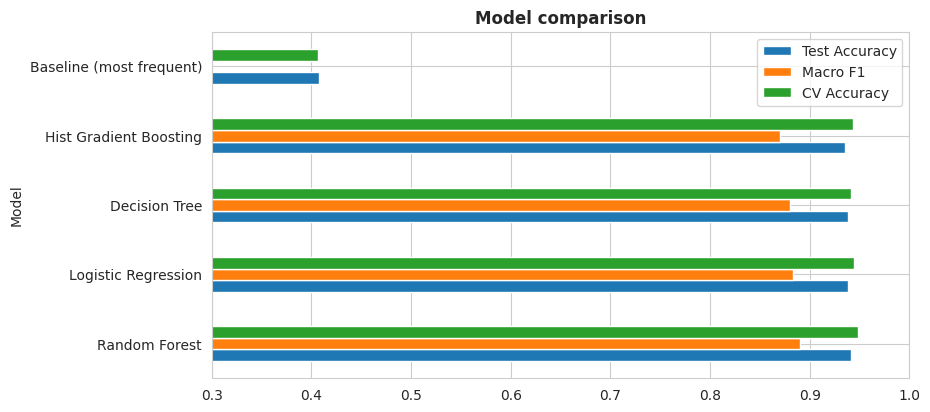

In [8]:
results.set_index('Model')[['Test Accuracy', 'Macro F1', 'CV Accuracy']].plot(kind='barh', figsize=(9, 4.5))
plt.xlim(0.3, 1); plt.title('Model comparison',fontweight='bold'); plt.show()

## **7. Tune the best model**

In [9]:
from sklearn.model_selection import GridSearchCV
rf_pipe = Pipeline([('prep', pre), ('model', RandomForestClassifier(random_state=42, n_jobs=-1))])
grid = {'model__n_estimators': [200, 400], 'model__max_depth': [8, 12, None], 'model__min_samples_leaf': [1, 3]}
gs = GridSearchCV(rf_pipe, grid, cv=3, scoring='f1_macro', n_jobs=-1).fit(X_train, y_train)
best = gs.best_estimator_; pred = best.predict(X_test)
print('Best params:', gs.best_params_)
print('Tuned RF  Accuracy: %.4f | Macro F1: %.4f' % (accuracy_score(y_test, pred), f1_score(y_test, pred, average='macro')))

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Tuned RF  Accuracy: 0.9387 | Macro F1: 0.8897


## **8. Evaluate the final model**

                              precision    recall  f1-score   support

Extreme / Half-Marathon Toll       0.97      0.97      0.97       652
          High Sweat Penalty       0.93      0.94      0.93       424
               Moderate Burn       0.77      0.71      0.74        38
       Severe Cardio Deficit       0.92      0.91      0.92       486

                    accuracy                           0.94      1600
                   macro avg       0.90      0.88      0.89      1600
                weighted avg       0.94      0.94      0.94      1600



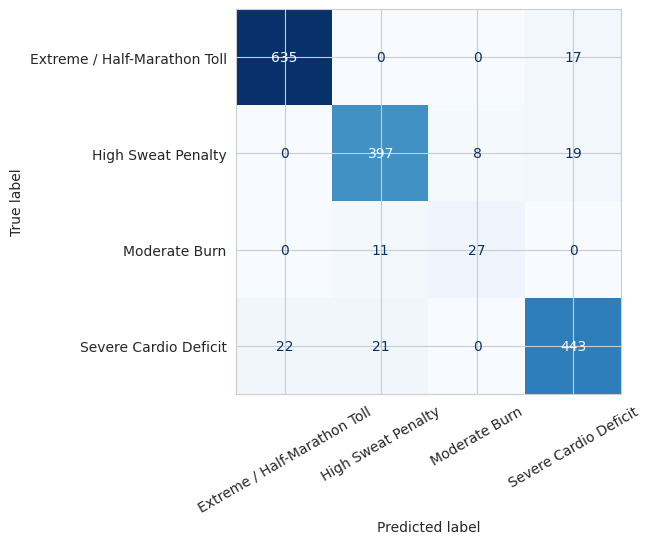

In [10]:
print(classification_report(y_test, pred, target_names=le.classes_))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=30, colorbar=False)
plt.show()

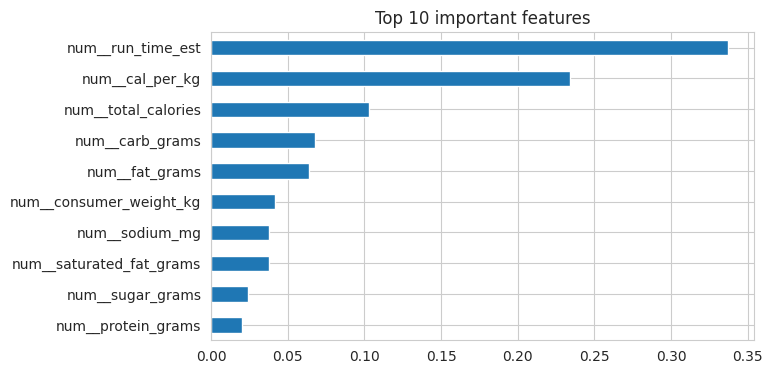

In [12]:
names = best.named_steps['prep'].get_feature_names_out()
imp = pd.Series(best.named_steps['model'].feature_importances_, index=names).sort_values().tail(10)
imp.plot(kind='barh', figsize=(7, 4), title='Top 10 important features'); plt.show()

## **9. Conclusion**

### **Key findings**
- **Data leakage avoided:** burn-time, surplus and allowance columns define the target, so they were excluded for an honest model.
- **Baseline** (always guess the biggest class) scores only ~41%, so the models are truly learning.
- **Random Forest** was the best model: about **94% accuracy** and **0.89 macro F1** (CV accuracy about 94.9%), slightly ahead of Logistic Regression, Decision Tree and Gradient Boosting.
- **Most important features:** the engineered `run_time_est` and `cal_per_kg`, then calories and weight. Simple domain features helped.
- **Weak spot:** `Moderate Burn` is rare (only 38 test rows), so its F1 (~0.74) is lower. Errors mostly happen between neighbouring tiers near the cut-offs.

### **Next steps**
Collect more rare-class samples, try SMOTE or XGBoost/LightGBM, and test other feature ideas.